
Final Centroids:
1 = (4.93, 5.05)
2 = (9.12, 1.16)
3 = (1.02, 1.02)
Cluster Assignments: 2 1 3 2 1 2 2 3 1 2 2 2 1 3 1 1 3 1 3 3 3 3 1 2 1 3 2 1 1 3 1 3 1 2 1 3 2 2 1 1 2 1 2 3 1 1 1 1 3 3 2 3 2 2 2 3 3 3 1 2 3 1 1 1 3 2 1 2 1 1 2 1 2 2 1 2 3 3 2 3 2 2 2 3 3 3 3 1 3 2 2 3 2 1 3 2 3 3 1 1 2 3 3 1 2 1 2 3 3 3 3 1 2 1 1 2 3 1 3 2 1 2 1 3 1 3 3 1 3 3 3 2 2 1 1 1 3 1 2 1 3 2 3 2 3 1 3 3 2 1 3 2 2 1 1 3 2 3 3 2 1 1 1 1 1 3 3 1 2 1 3 2 2 3 3 1 2 3 1 3 2 1 3 3 3 3 1 2 3 2 3 2 1 2 1 1 1 1 2 3 2 3 3 3 2 3 3 2 2 2 2 3 2 3 3 1 3 1 1 2 1 1 2 1 3 2 2 3 1 3 2 2 3 2 2 2 2 2 2 2 3 1 2 2 3 1 2 1 3 1 2 2 3 3 2 3 1 3 2 1 2 1 2 3 2 3 3 3 1 2 3 1 1 2 3 3 3 3 1 3 2 1 1 3 2 3 1 3 3 1 3 3 3 2 3 3 3 3 1 3 3 1 2 3 3 1 1 1 2 2 2 2 2 1 3 3 1 2 3 3 1 3 3 1 2 2 3 1 2 2 3 2 2 2 2 2 2 1 2 3 2 2 3 3 2 1 2 3 3 1 1 2 2 1 1 1 3 1 2 1 3 3 2 2 2 1 1 3 3 2 2 3 3 3 1 2 2 2 1 3 1 1 1 3 3 2 2 1 3 2 1 2 1 3 1 1 1 2 1 1 2 3 1 3 2 3 2 3 1 2 2 1 1 2 3 3 3 3 1 2
Final Cost J = 1.26


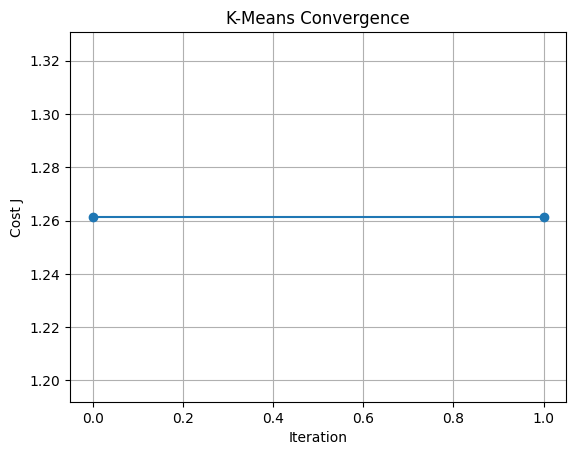

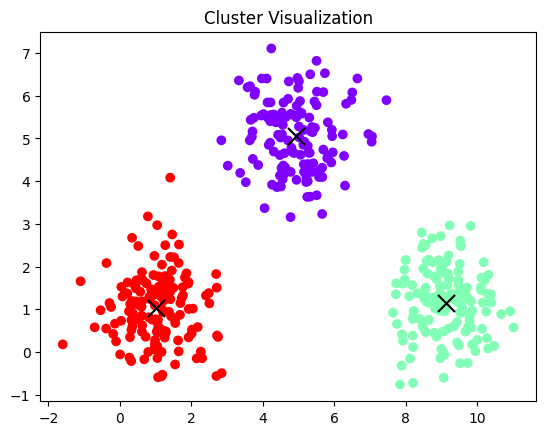

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def load_csv(filename):
    return np.loadtxt(filename, delimiter=',')

def initialize_centroids(X, K):
    np.random.seed(0)
    indices = np.random.choice(X.shape[0], K, replace=False)
    return X[indices]

def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, K):
    centroids = np.zeros((K, X.shape[1]))
    for k in range(K):
        cluster_points = X[labels == k]
        if len(cluster_points) == 0:
            centroids[k] = X[np.random.choice(X.shape[0])]
        else:
            centroids[k] = cluster_points.mean(axis=0)
    return centroids

def compute_cost(X, labels, centroids):
    return np.mean(np.sum((X - centroids[labels])**2, axis=1))

def kmeans(X, K, max_iters=100):
    centroids = initialize_centroids(X, K)
    prev_labels = None
    J_history = []

    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        centroids = update_centroids(X, labels, K)
        J = compute_cost(X, labels, centroids)
        J_history.append(J)
        if np.all(labels == prev_labels):
            break
        prev_labels = labels
    return centroids, labels, J_history

def main():
    X_train = load_csv('k_means_train.csv')
    K = int(input("Enter number of clusters (K): "))
    iterations = int(input("Enter max iterations: "))

    centroids, labels, J_history = kmeans(X_train, K, iterations)

    print("\nFinal Centroids:")
    for i, c in enumerate(centroids, 1):
        print(f"{i} = ({c[0]:.2f}, {c[1]:.2f})")

    print("Cluster Assignments:", ' '.join(map(str, labels + 1)))
    print(f"Final Cost J = {J_history[-1]:.2f}")

    plt.plot(J_history, marker='o')
    plt.title("K-Means Convergence")
    plt.xlabel("Iteration")
    plt.ylabel("Cost J")
    plt.grid(True)
    plt.show()

    if X_train.shape[1] == 2:
        plt.scatter(X_train[:, 0], X_train[:, 1], c=labels, cmap='rainbow')
        plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='x', s=150)
        plt.title("Cluster Visualization")
        plt.show()

if __name__ == "__main__":
    main()
